In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import symlib
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

### claude written code

In [4]:
class Symphony_SubhaloCounter:
    """
    Measure subhalo statistics above a mass threshold within R_vir
    for each host halo in a symlib simulation suite.

    Parameters
    ----------
    base_dir       : base directory of the simulation suite (str)
    suite_name     : name of the simulation suite (str)
    mass_threshold : minimum subhalo mass to count (float, default 1e9 M_sun)

    Attributes
    ----------
    df : pandas DataFrame with columns:
        logMvir   - log10 host virial mass at z=0
        log1pz50  - log10(1 + z_50), where z_50 is the half-mass redshift
        logc      - log10 host concentration at z=0
        logMs     - log10 mass of most massive surviving subhalo within R_vir
        logNsub   - log10 number of subhalos within R_vir above threshold
        logfsub   - log10 subhalo mass fraction (Ms_tot / Mvir)
    """

    def __init__(self, base_dir, suite_name, mass_threshold):
        self.base_dir        = base_dir
        self.suite_name      = suite_name
        self.mass_threshold  = mass_threshold
        self.n_hosts         = symlib.n_hosts(suite_name)

        self.df = self._build()

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------
    def _find_nearest(self, array, value):
        return (np.abs(array - value)).argmin()

    def _process_host(self, i_host):
        """
        Process a single host halo and return a dict of statistics,
        or None if the host should be skipped.
        """
        sim_dir = symlib.get_host_directory(self.base_dir, self.suite_name, i_host)

        r, hist  = symlib.read_rockstar(sim_dir)
        s, hist  = symlib.read_symfind(sim_dir)

        h, hist2 = symlib.read_subhalos(sim_dir)
        scale    = symlib.scale_factors(sim_dir)

        # ------------------------------------------------------------------
        # Host halo properties
        # ------------------------------------------------------------------
        ok_host   = r[0, :]["ok"]
        a         = scale[ok_host]
        Mhost     = r[0, ok_host]["m"]
        Mhost_z0  = Mhost[-1]
        chost_z0  = r[0, ok_host]["cvir"][-1]
        host_rvir = r[0, -1]["rvir"]

        # half-mass redshift z50
        a50 = a[self._find_nearest(Mhost, Mhost_z0 / 2)]
        z50 = 1. / a50 - 1.

        # ------------------------------------------------------------------
        # Subhalo selection: within R_vir, alive at z=0, above mass threshold
        # ------------------------------------------------------------------
        sub_x = h[:, -1]["x"]
        r_3d  = np.sqrt(np.sum(sub_x**2, axis=1))
        ok    = h["ok"][:, -1]

        msub_all = np.array([r[i, -1]["m"] for i in range(1, len(r))])

        within_rvir  = r_3d[1:] < host_rvir
        above_thresh = msub_all > self.mass_threshold
        ok_subs      = ok[1:] & within_rvir & above_thresh

        msub_selected = msub_all[ok_subs]

        MMs  = np.max(msub_selected)
        M_sub  = np.sum(msub_selected)
        f_sub  = M_sub / Mhost_z0
        N_sub = len(msub_selected)

        if MMs < self.mass_threshold:
            MMs = 0
            f_sub = 0
            N_sub = 0

        return {
        "logMvir":  np.log10(Mhost_z0),
        "log1pz50": np.log10(1 + z50),
        "logc":     np.log10(chost_z0),
        "Nsub":     N_sub,
        "logNsub":  np.log10(N_sub),
        "fsub":     f_sub,
        "logfsub":  np.log10(f_sub),
        "MMs":   MMs / Mhost_z0,
        "logMMs":   np.log10(MMs / Mhost_z0)}
    

    def _build(self):
        """Loop over all hosts and collect results into a DataFrame."""
        rows = []
        for i_host in range(self.n_hosts):
            try:
                row = self._process_host(i_host)
                if row is not None:
                    rows.append(row)
            except Exception as e:
                print(f"Error processing i_host={i_host}: {e}")
                continue

        return pd.DataFrame(rows, columns=['logMvir', 'log1pz50', 'logc',
                                           'Nsub', 'logNsub',
                                           'fsub', 'logfsub',
                                           'MMs', 'logMMs']).replace([np.inf, -np.inf], np.nan)


In [ ]:
# sym_fid = Symphony_SubhaloCounter("/Users/jsmonzon/Research/Misc/Symphony/", "SymphonyMilkyWay", 1e9)
# sym_fid.df.to_csv("../../data/summary_tabs/MW/symphony/m12s.csv")

In [19]:
sym_fid = pd.read_csv("../../data/summary_tabs/MW/symphony/m12s.csv")

(0.0, 25.0)

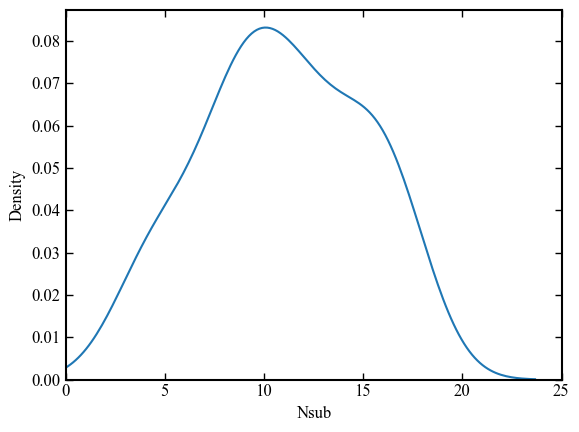

In [20]:
sns.kdeplot(sym_fid["Nsub"])
plt.xlim(0,25)

In [21]:
sym_rhoz_fid, sym_rho_errz_fid, _ = jsm_stats.jackknife_correlation(sym_fid["log1pz50"], sym_fid["Nsub"])

sym_rhoc_fid, sym_rho_errc_fid, _ = jsm_stats.jackknife_correlation(sym_fid["logc"], sym_fid["Nsub"])

sym_rhom_fid, sym_rho_errm_fid, _ = jsm_stats.jackknife_correlation(sym_fid["MMs"], sym_fid["Nsub"])

In [22]:
sym_rhoz_fid

-0.5713039233116376

In [23]:
sym_rhoc_fid

-0.559596592038242

In [24]:
sym_rhom_fid

0.6003281884810586

In [25]:
sym_rho_errm_fid

0.10252726103434535

In [26]:
# SHR = jsm_ancillary.load_sample("../../../StellarHalo/data/fiducial/S0HR_sample.h5")
# SLR = jsm_ancillary.load_sample("../../../StellarHalo/data/fiducial/S0_sample.h5")

In [27]:
# def short(sample, mass_res):

#     final_mass = jsm_ancillary.make_matrix(sample, "sat_mass")
#     final_rmag = jsm_ancillary.make_matrix(sample, "sat_final_rmag")


#     try:
#         host_rvir = jsm_ancillary.make_matrix(sample, "host_Rvir")[:, 0]
#     except TypeError:
#         host_rvir = sample["host_Rvir"].values
        
#     z50 = np.log10(1 + sample["host_z50"].values)

#     # Apply Rvir mask using the final (0th index) host Rvir per host
#     rvir_mask = final_rmag <= host_rvir[:, np.newaxis]
#     final_mass = np.where(rvir_mask, final_mass, np.nan)
#     Nsub = np.sum(final_mass > mass_res, axis=1)

#     return Nsub

In [9]:
# # sns.kdeplot(short(SLR, 1e8), c="C0")
# sns.kdeplot(short(SLR, 3e8), c="C1")
# sns.kdeplot(short(SLR, 7e8), c="C2")
# sns.kdeplot(short(SLR, 1e9), c="C3")
# sns.kdeplot(short(SLR, 2e9), c="C4")

# # sns.kdeplot(short(SHR, 1e8), ls="--", c="C0")
# sns.kdeplot(short(SHR, 3e8), ls="--", c="C1")
# sns.kdeplot(short(SHR, 7e8), ls="--", c="C2")
# sns.kdeplot(short(SHR, 1e9), ls="--", c="C3")
# sns.kdeplot(short(SHR, 2e9), ls="--", c="C4")